# Leduc Poker — Algorithm Comparison

Compare four MCCFR variants on Leduc Poker by exploitability vs. iterations:

| Variant   | alpha | beta | gamma | clip  |
|-----------|-------|------|-------|-------|
| LCFR      | 1     | 1    | 1     | False |
| DCFR      | 1.5   | 0    | 2     | False |
| DCFR+     | 1.5   | 0    | 2     | True  |
| MCCFR+    | inf   | inf  | inf   | True  |

All variants share the same External-Sampling MCCFR base; they differ only in regret/strategy averaging.
Exploitability is computed exactly by enumerating all Leduc deals (120 of them).

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import numpy as np
from itertools import permutations
from src.algorithms.mccfr import MCCFR
from src.training.leduc_poker import LeducPokerRules

## Variant definitions

Each entry is a factory `(game) -> MCCFR(...)` so the training loop is variant-agnostic.

In [2]:
INF = float('inf')

VARIANTS = {
    'LCFR':   lambda game: MCCFR(game, alpha=1.0, beta=1.0, gamma=1.0, clip=False),
    'DCFR':   lambda game: MCCFR(game, alpha=1.5, beta=0.0, gamma=2.0, clip=False),
    'DCFR+':  lambda game: MCCFR(game, alpha=1.5, beta=0.0, gamma=2.0, clip=True),
    'MCCFR+': lambda game: MCCFR(game, alpha=INF, beta=INF, gamma=INF, clip=True),
}

VARIANT_COLORS = {
    'LCFR':   'tab:blue',
    'DCFR':   'tab:orange',
    'DCFR+':  'tab:red',
    'MCCFR+': 'tab:green',
}

## Exploitability computation

Iterated best-response over the public game tree. Exact on Leduc (120 deals).

In [3]:
def _get_all_deals(game):
    return list(permutations([0, 1, 2, 3, 4, 5], 3))


def _node_info(game, cards, history):
    player = game.get_acting_player(history)
    player_card = cards[player]
    flop = cards[2] if len(cards) > 2 else None
    return player, player_card, (flop, None, None)


def _traverse_br(game, opp_strategy, br_pure, br_player, cards, history, opp_reach, cf_values):
    player, player_card, com_cards = _node_info(game, cards, history)

    if game.is_terminal(history):
        sign = 1 if br_player == 0 else -1
        return opp_reach * sign * game.get_payoff(cards[:2], history, com_cards)

    actions = game.get_legal_actions(history)
    info_set_key = game.get_info_set_string(player_card, history, com_cards)

    if player == br_player:
        if info_set_key not in cf_values:
            cf_values[info_set_key] = [0.0] * len(actions)

        action_vals = []
        for i, action in enumerate(actions):
            val = _traverse_br(game, opp_strategy, br_pure, br_player, cards,
                               history + action, opp_reach, cf_values)
            cf_values[info_set_key][i] += val
            action_vals.append(val)

        if info_set_key in br_pure:
            return action_vals[br_pure[info_set_key]]
        return max(action_vals)
    else:
        strat = opp_strategy.get(info_set_key, [1.0 / len(actions)] * len(actions))
        ev = 0.0
        for i, action in enumerate(actions):
            ev += _traverse_br(game, opp_strategy, br_pure, br_player, cards,
                               history + action, opp_reach * strat[i], cf_values)
        return ev


def _eval_br(game, opp_strategy, br_pure, br_player, cards, history, opp_reach):
    player, player_card, com_cards = _node_info(game, cards, history)

    if game.is_terminal(history):
        sign = 1 if br_player == 0 else -1
        return opp_reach * sign * game.get_payoff(cards[:2], history, com_cards)

    actions = game.get_legal_actions(history)
    info_set_key = game.get_info_set_string(player_card, history, com_cards)

    if player == br_player:
        chosen = br_pure.get(info_set_key, 0)
        return _eval_br(game, opp_strategy, br_pure, br_player, cards,
                        history + actions[chosen], opp_reach)
    else:
        strat = opp_strategy.get(info_set_key, [1.0 / len(actions)] * len(actions))
        ev = 0.0
        for i, action in enumerate(actions):
            ev += _eval_br(game, opp_strategy, br_pure, br_player, cards,
                           history + action, opp_reach * strat[i])
        return ev


def compute_exploitability(game, strategy):
    deals = _get_all_deals(game)
    total_expl = 0.0
    for br_player in [0, 1]:
        br_pure = {}
        for _ in range(20):
            cf_values = {}
            for deal in deals:
                _traverse_br(game, strategy, br_pure, br_player, deal, '', 1.0, cf_values)
            new_br_pure = {key: max(range(len(av)), key=lambda i, av=av: av[i])
                           for key, av in cf_values.items()}
            if new_br_pure == br_pure:
                break
            br_pure = new_br_pure

        br_value = sum(
            _eval_br(game, strategy, br_pure, br_player, deal, '', 1.0)
            for deal in deals
        ) / len(deals)
        total_expl += br_value
    return total_expl / 2.0

## Training helper

Generic over the variant factory.

In [4]:
def train_with_checkpoints(factory, game, total_iterations, num_checkpoints, label=''):
    algo = factory(game)
    checkpoint_interval = max(1, total_iterations // num_checkpoints)

    iters, expls = [], []
    current = 0
    for i in range(num_checkpoints):
        algo.train(checkpoint_interval)
        current += checkpoint_interval
        expl = compute_exploitability(game, algo.get_strategy())
        iters.append(current)
        expls.append(expl)
        if (i + 1) % 10 == 0:
            print(f'  [{label}] iter {current:>8d}  expl {expl:.6f}')
    return iters, expls, algo

## Train all four variants

Same iteration budget and checkpoint cadence for every variant so the curves are directly comparable.

In [5]:
TOTAL_ITERATIONS = 500_000
NUM_CHECKPOINTS = 50

results = {}
trained = {}
for name, factory in VARIANTS.items():
    print(f'Training {name}...')
    game = LeducPokerRules()
    iters, expls, algo = train_with_checkpoints(
        factory, game, TOTAL_ITERATIONS, NUM_CHECKPOINTS, label=name
    )
    results[name] = (iters, expls)
    trained[name] = algo
    print(f'  final expl {expls[-1]:.6f}\n')

Training LCFR...
  [LCFR] iter   100000  expl 0.327344
  [LCFR] iter   200000  expl 0.328825
  [LCFR] iter   300000  expl 0.287771
  [LCFR] iter   400000  expl 0.270855
  [LCFR] iter   500000  expl 0.291511
  final expl 0.291511

Training DCFR...
  [DCFR] iter   100000  expl 0.070392
  [DCFR] iter   200000  expl 0.052035
  [DCFR] iter   300000  expl 0.041804
  [DCFR] iter   400000  expl 0.037616
  [DCFR] iter   500000  expl 0.034156
  final expl 0.034156

Training DCFR+...
  [DCFR+] iter   100000  expl 0.083708
  [DCFR+] iter   200000  expl 0.065061
  [DCFR+] iter   300000  expl 0.053873
  [DCFR+] iter   400000  expl 0.043281
  [DCFR+] iter   500000  expl 0.039912
  final expl 0.039912

Training MCCFR+...
  [MCCFR+] iter   100000  expl 0.066458
  [MCCFR+] iter   200000  expl 0.051610
  [MCCFR+] iter   300000  expl 0.043322
  [MCCFR+] iter   400000  expl 0.036136
  [MCCFR+] iter   500000  expl 0.031739
  final expl 0.031739



## Convergence curves

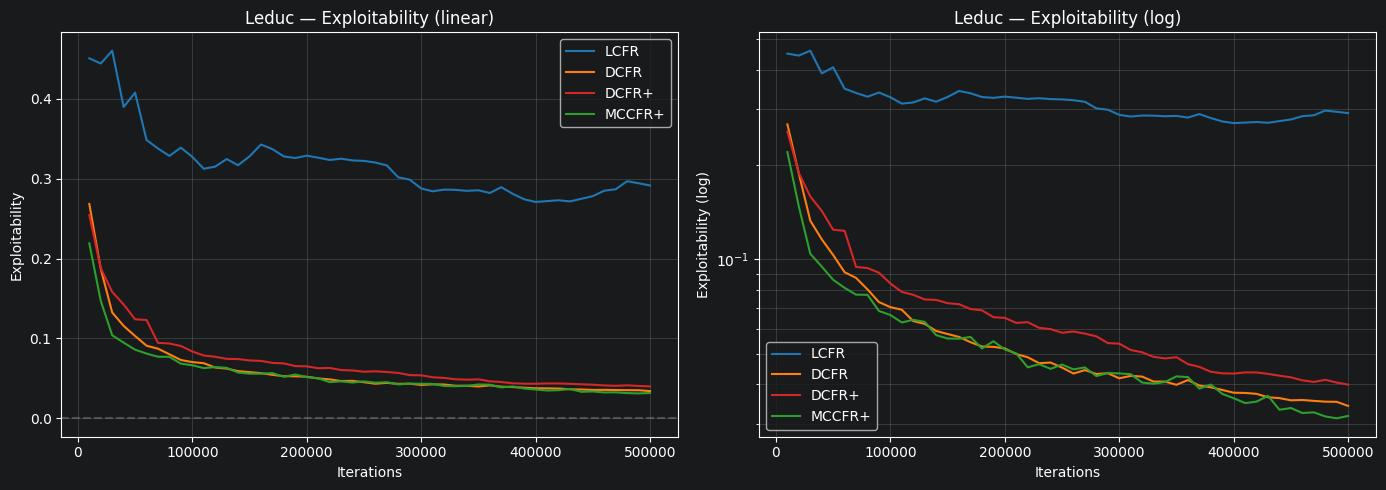

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax in axes:
    for name, (iters, expls) in results.items():
        ax.plot(iters, expls, color=VARIANT_COLORS[name], linewidth=1.5, label=name)
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('Iterations')
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')

axes[0].set_ylabel('Exploitability')
axes[0].set_title('Leduc — Exploitability (linear)')
axes[1].set_ylabel('Exploitability (log)')
axes[1].set_title('Leduc — Exploitability (log)')
axes[1].set_yscale('log')
plt.tight_layout()
plt.show()

## Summary table

Final exploitability + log-log convergence slope over the last half of training.

In [7]:
print(f"{'Variant':<10} {'Final expl':>14} {'Log-log slope':>16} {'Info sets':>12}")
print('-' * 56)
for name, (iters, expls) in results.items():
    half = len(iters) // 2
    log_iters = np.log(iters[half:])
    log_expl = np.log(np.maximum(expls[half:], 1e-12))
    slope = np.polyfit(log_iters, log_expl, 1)[0]
    n_info = len(trained[name].info_sets)
    print(f'{name:<10} {expls[-1]:>14.6f} {slope:>16.3f} {n_info:>12,}')

Variant        Final expl    Log-log slope    Info sets
--------------------------------------------------------
LCFR             0.291511           -0.118          528
DCFR             0.034156           -0.398          528
DCFR+            0.039912           -0.593          528
MCCFR+           0.031739           -0.588          528
